In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

# Regresión logística con statsmodels

## ¿Qué es la regresión logística?

La regresión logística es un modelo estadístico que se utiliza cuando la variable objetivo es **binaria**, es decir, solo puede tomar dos valores posibles:

- 0 = No
- 1 = Sí

Ejemplos:
- Spam / No spam
- Compra / No compra
- Pingüino macho / hembra

---

## Diferencia con regresión lineal

En regresión lineal:

$$
y = \beta_0 + \beta_1 x
$$

Pero en clasificación necesitamos probabilidades entre 0 y 1.

---

## Función logística (sigmoide)

$$
p(x) = \frac{1}{1 + e^{-(\beta_0 + \beta_1 x)}}
$$

Esta función transforma cualquier número real en un valor entre 0 y 1.

---

## Interpretación

El modelo estima:

$$
P(Y=1 \mid X)
$$

Ejemplo:
- 0.80 → 80% probabilidad de ser clase 1
- 0.20 → 20% probabilidad

Regla de decisión:

- Si $p \geq 0.5$ → clase 1
- Si $p < 0.5$ → clase 0

---

## Modelo logístico (logit)

La regresión logística modela el logaritmo de las odds:

$$
\log \left( \frac{p}{1-p} \right) = \beta_0 + \beta_1 x
$$

Donde:

- $p$ = probabilidad
- $\frac{p}{1-p}$ = odds
- $\log(\frac{p}{1-p})$ = logit

## QUEREMOS CREAR UN MODELO QUE PERMITA DETERMINAR EL SEXO DEL UN PINGUINO

In [2]:
penguins_df = sns.load_dataset('penguins')
penguins_df.dropna(inplace=True)
penguins_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


# AGREGAMOS VARIABLE NÚMERICA DEPENDIENTE EN BASE AL SEXO

In [3]:
penguins_df = (
    penguins_df.assign(numeric_sex=lambda df: df.sex.replace(['Female','Male'],[0,1]))
)
penguins_df

/tmp/ipykernel_6645/283968879.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  penguins_df.assign(numeric_sex=lambda df: df.sex.replace(['Female','Male'],[0,1]))


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,numeric_sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,1
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,0
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,0
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,0
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,1
...,...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female,0
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female,0
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male,1
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female,0


# APLICAMOS EL MODELO REGRESIÓN LOGISTICA

In [5]:
model_sex = smf.logit(
    formula = 'numeric_sex ~ flipper_length_mm + bill_length_mm + bill_depth_mm + C(island) + C(species)',
    data = penguins_df
).fit()

model_sex.params

Optimization terminated successfully.
         Current function value: 0.264693
         Iterations 8


,0
Intercept,-82.344464
C(island)[T.Dream],0.393351
C(island)[T.Torgersen],-0.659830
C(species)[T.Chinstrap],-8.247883
C(species)[T.Gentoo],-1.282189
flipper_length_mm,0.099514
bill_length_mm,0.661924
bill_depth_mm,2.064121


# HACEMOS UN PREDICCIÓN CON NUESTRO MODELO

In [6]:
is_male_predictions = pd.DataFrame(
    dict(
        actual_value = penguins_df.numeric_sex,
        predicted_value = model_sex.predict().round()
    )
)
is_male_predictions

,actual_value,predicted_value
0,1,0.0
1,0,0.0
2,0,1.0
4,0,1.0
5,1,1.0
...,...,...
338,0,0.0
340,0,0.0
341,1,1.0
342,0,0.0


# MATRIZ DE CONFUSIÓN

In [7]:
from sklearn.metrics import confusion_matrix

conf_matrix = confusion_matrix(is_male_predictions.actual_value,is_male_predictions.predicted_value)
conf_matrix

array([[146,  19],
       [ 20, 148]])

/tmp/ipykernel_6645/3614695187.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


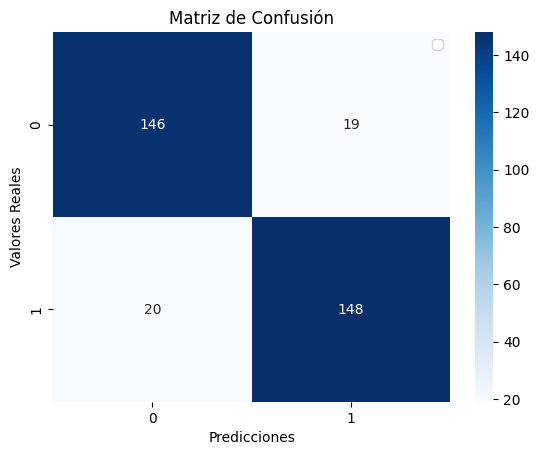

In [8]:
sns.heatmap(conf_matrix,annot=True,fmt='d',cmap='Blues')
plt.xlabel('Predicciones')
plt.ylabel('Valores Reales')
plt.title('Matriz de Confusión')
plt.legend()
plt.show()

# ACCURACY

In [9]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(is_male_predictions['actual_value'],is_male_predictions['predicted_value'])
print(f'Accuracy : {accuracy:.4f}')

Accuracy : 0.8829
